In [95]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats

In [96]:
p = [0.10, 0.41, 0, 0.334]
q = [0.11, 0.45, 0.12, 0.345]

In [97]:
def kl(p,q):
  return np.sum(np.where(np.logical_and(p!=0, q!=0), p*np.log(p/q), 0))

In [98]:
x = np.arange(-10, 10, 0.001)
len(x)

20000

In [99]:
p = stats.norm.pdf(x, 0, 2)
q = stats.norm.pdf(x, 2, 3)

In [100]:
print(max(p))
print(max(q))

0.19947114020071635
0.1329807601338109


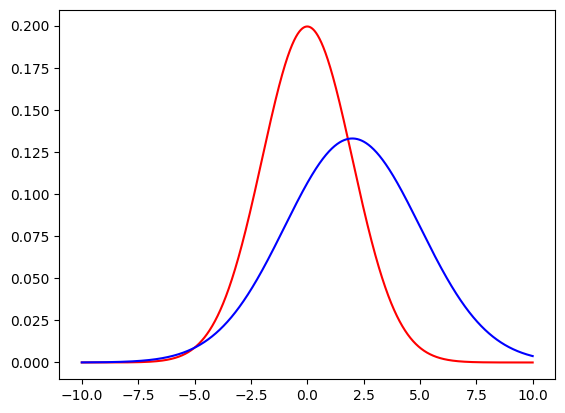

In [101]:
plt.plot(x, p, c = "red")
plt.plot(x, q, c = "blue")
plt.show()

In [102]:
print(f"kullback-Leibler: {kl(p,q)}")

kullback-Leibler: 349.91348337868124


In [103]:
p = stats.norm.pdf(x, 0, 2)
q = stats.norm.pdf(x, 0.01, 2.2)

In [104]:
print(max(p))
print(max(q))

0.19947114020071635
0.18133740018246938


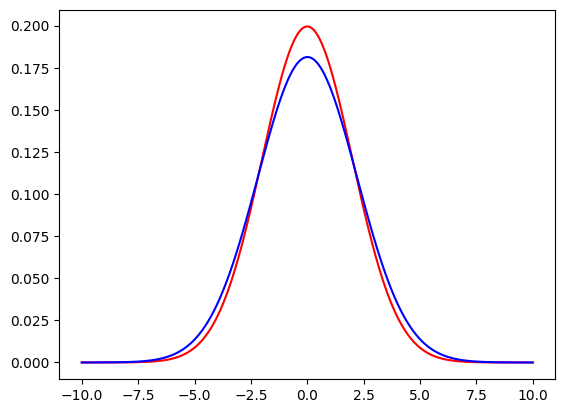

In [105]:
plt.plot(x, p, c = "red")
plt.plot(x, q, c = "blue")
plt.show()

In [106]:
print(f"kullback-Leibler: {kl(p,q)}")

kullback-Leibler: 8.544936125059738


In [107]:
mean = [0, 1, 0.1, 0.01, 0.001]
std = [2, 2.1, 2.3, 3, 5]
kl_arr = []
mean_arr = []
std_arr = []
p = stats.norm.pdf(x, 0, 2)

for i in mean:
  for j in std:
    q = stats.norm.pdf(x, i, j)
    mean_arr.append(i)
    std_arr.append(j)
    kl_arr.append(kl(p,q))

In [108]:
df = pd.DataFrame({"mean": mean_arr, "std": std_arr, "kl": kl_arr})
df

,mean,std,kl
0,0.000,2.0,0.000000
1,0.000,2.1,2.305593
2,0.000,2.3,17.835579
3,0.000,3.0,127.691387
4,0.000,5.0,496.296692
5,1.000,2.0,124.999930
6,1.000,2.1,115.684215
7,1.000,2.3,112.353484
8,1.000,3.0,183.246911
9,1.000,5.0,516.296680


In [109]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [110]:
data = pd.read_csv("/content/drive/MyDrive/Statistic/weight-height.csv")
data

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [111]:
data.groupby("Gender").mean()

,Height,Weight
Gender,,
Female,63.708774,135.860093
Male,69.026346,187.020621


In [112]:
males = data[data["Gender"] == "Male"]["Height"]
females = data[data["Gender"] == "Female"]["Height"]

In [113]:
males.describe()


,Height
count,5000.000000
mean,69.026346
std,2.863362
min,58.406905
25%,67.174679
50%,69.027709
75%,70.988744
max,78.998742


In [114]:
females.describe()

,Height
count,5000.000000
mean,63.708774
std,2.696284
min,54.263133
25%,61.894441
50%,63.730924
75%,65.563565
max,73.389586


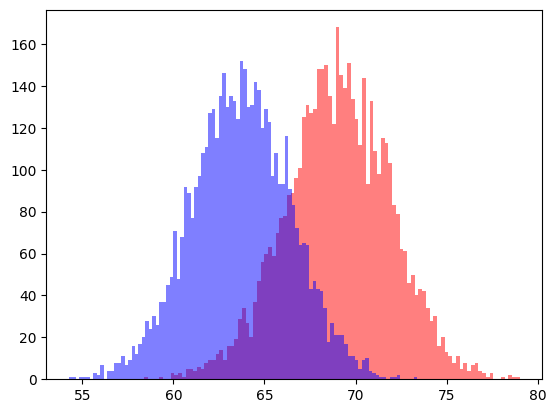

In [115]:
plt.hist(males, bins =100, alpha = 0.5, label = "males", color="red")
plt.hist(females, bins =100, alpha = 0.5, label = "females", color="blue")
plt.show()

In [116]:
count, devision = np.histogram(males, bins = 100)
print(count)
print(devision)

[  1   0   0   0   1   0   0   3   2   3   1   5   5   4   6   5   8   9
   9  12  14   9  16  16  19  29  34  27  20  37  47  56  60  63  59  70
  77  78  88  89  96 101 125 131 127 129 148 148 150 135 122 168 145 139
 151 134 124 112 144  93 133 109  98 115 113 103  83  79  62  61  46  50
  40  43  42  34  28  30  16  20  13  11   8  11   5   8   4   7   8   4
   3   1   3   0   0   1   0   2   1   1]
[58.40690493 58.61282331 58.81874168 59.02466005 59.23057843 59.4364968
 59.64241518 59.84833355 60.05425192 60.2601703  60.46608867 60.67200705
 60.87792542 61.0838438  61.28976217 61.49568054 61.70159892 61.90751729
 62.11343567 62.31935404 62.52527241 62.73119079 62.93710916 63.14302754
 63.34894591 63.55486429 63.76078266 63.96670103 64.17261941 64.37853778
 64.58445616 64.79037453 64.9962929  65.20221128 65.40812965 65.61404803
 65.8199664  66.02588478 66.23180315 66.43772152 66.6436399  66.84955827
 67.05547665 67.26139502 67.46731339 67.67323177 67.87915014 68.08506852
 68.290986

In [117]:
ideal = stats.norm.rvs(size = len(males), loc = males.describe()[1], scale = males.describe()[2])
print(ideal)

[67.68283086 77.7553838  71.72345875 ... 72.03015061 72.9660185
 70.6442088 ]


/tmp/ipython-input-10112309.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ideal = stats.norm.rvs(size = len(males), loc = males.describe()[1], scale = males.describe()[2])
/tmp/ipython-input-10112309.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ideal = stats.norm.rvs(size = len(males), loc = males.describe()[1], scale = males.describe()[2])


In [118]:
icount, idevision = np.histogram(ideal, bins = 100)
print(icount)
print(idevision)

[  1   0   1   3   1   1   0   1   0   1   3   1   1   5   9   5   8   6
   5   6  16  12  12  21  23  30  34  42  45  43  56  49  48  84  65  71
  95 106  91 110 126 127 145 105 134 145 149 165 136 162 138 130 151 138
 129 150 119 142 126 100 132  93 102  97  84  67  66  68  56  58  58  44
  43  31  23  22  23  12  13  15   7  15  10   6   3   5   3   0   1   3
   2   1   2   1   2   1   0   1   0   2]
[58.4617215  58.67339297 58.88506445 59.09673593 59.30840741 59.52007889
 59.73175037 59.94342184 60.15509332 60.3667648  60.57843628 60.79010776
 61.00177924 61.21345071 61.42512219 61.63679367 61.84846515 62.06013663
 62.27180811 62.48347958 62.69515106 62.90682254 63.11849402 63.3301655
 63.54183698 63.75350845 63.96517993 64.17685141 64.38852289 64.60019437
 64.81186585 65.02353732 65.2352088  65.44688028 65.65855176 65.87022324
 66.08189472 66.29356619 66.50523767 66.71690915 66.92858063 67.14025211
 67.35192359 67.56359506 67.77526654 67.98693802 68.1986095  68.41028098
 68.621952

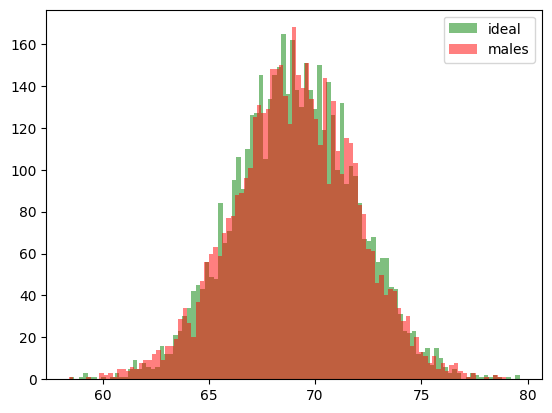

In [119]:
plt.hist(ideal, bins =100, alpha = 0.5, label = "ideal", color="green")
plt.hist(males, bins =100, alpha = 0.5, label = "males", color="red")
plt.legend()
plt.show()

In [120]:
print(kl(count, icount))

132.9974299483361


/tmp/ipython-input-3555337909.py:2: RuntimeWarning: divide by zero encountered in divide
  return np.sum(np.where(np.logical_and(p!=0, q!=0), p*np.log(p/q), 0))
/tmp/ipython-input-3555337909.py:2: RuntimeWarning: invalid value encountered in divide
  return np.sum(np.where(np.logical_and(p!=0, q!=0), p*np.log(p/q), 0))
/tmp/ipython-input-3555337909.py:2: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.where(np.logical_and(p!=0, q!=0), p*np.log(p/q), 0))
/tmp/ipython-input-3555337909.py:2: RuntimeWarning: invalid value encountered in multiply
  return np.sum(np.where(np.logical_and(p!=0, q!=0), p*np.log(p/q), 0))


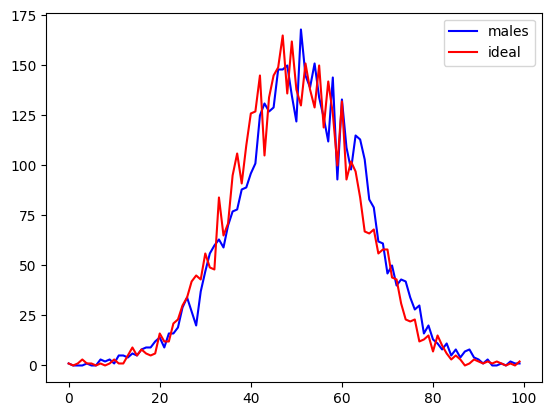

In [121]:
plt.plot(count, c='blue', label = "males")
plt.plot(icount, c='red', label = "ideal")
plt.legend()
plt.show()

In [122]:
count.sum()

np.int64(5000)

In [123]:
count = count/count.sum()
icount = icount/icount.sum()

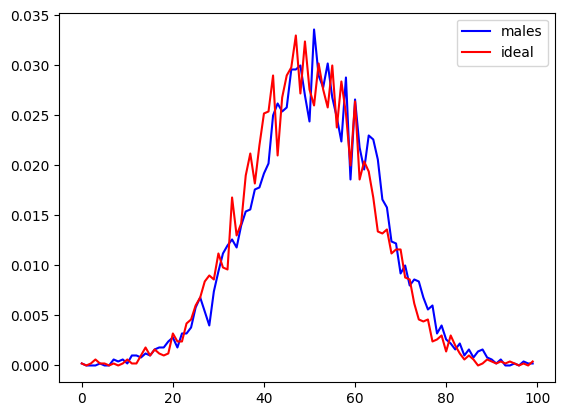

In [124]:
plt.plot(count, c='blue', label = "males")
plt.plot(icount, c='red', label = "ideal")
plt.legend()
plt.show()

In [127]:
print(kl(count, icount))

0.02659948598966722


/tmp/ipython-input-3555337909.py:2: RuntimeWarning: divide by zero encountered in divide
  return np.sum(np.where(np.logical_and(p!=0, q!=0), p*np.log(p/q), 0))
/tmp/ipython-input-3555337909.py:2: RuntimeWarning: invalid value encountered in divide
  return np.sum(np.where(np.logical_and(p!=0, q!=0), p*np.log(p/q), 0))
/tmp/ipython-input-3555337909.py:2: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.where(np.logical_and(p!=0, q!=0), p*np.log(p/q), 0))
/tmp/ipython-input-3555337909.py:2: RuntimeWarning: invalid value encountered in multiply
  return np.sum(np.where(np.logical_and(p!=0, q!=0), p*np.log(p/q), 0))


In [125]:
males = data[data["Gender"] == "Male"]["Weight"]
females = data[data["Gender"] == "Female"]["Weight"]

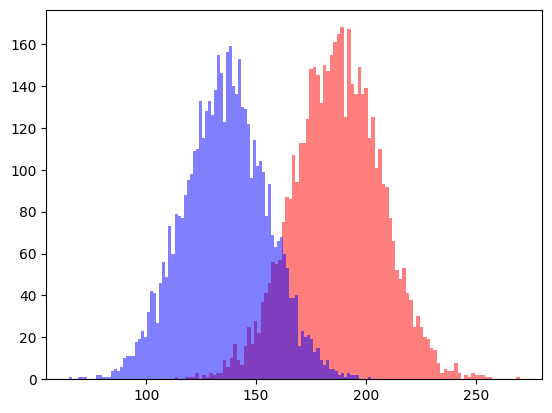

In [126]:
plt.hist(males, bins =100, alpha = 0.5, label = "males", color="red")
plt.hist(females, bins =100, alpha = 0.5, label = "females", color="blue")
plt.show()